In [2]:
from enum import Enum


class Priority(Enum):
    LOW = 0
    MEDIUM = 1
    HIGH = 2
    CRITICAL = 3


class Category(Enum):
    PAYMENT = 0
    DELIVERY = 1
    TECH = 2
    PRODUCT = 3
    SPAM = 4

In [3]:
dataset_path = 'DatasetFiles'

In [4]:
import os
import json
import numpy as np
import pandas as pd

In [5]:
total_tests = 0
tests_list = []
for file in os.listdir(dataset_path):
    if not file.endswith('.json'):
        continue
    
    file_path = os.path.join(dataset_path, file)
    with open(file_path, "r", encoding="utf-8") as json_file:
        try:
            json_object = json.load(json_file)
            if type(json_object)!= list: continue
            tests_list += json_object
            total_tests += len(json_object)
            print(f"{file} загружен успешно, {len(json_object)} записей")
        except json.JSONDecodeError as e:
            print(f"Ошибка {e} при загрузке {file}")

dataset_deepseek.json загружен успешно, 510 записей
dataset_emotional.json загружен успешно, 21 записей
dataset_chad.json загружен успешно, 81 записей


In [6]:
total_tests

612

In [67]:
from collections import Counter

test_types = [(test["category"], test["priority"]) for test in tests_list]
categories = [test["category"] for test in tests_list]
priorities = [test["priority"] for test in tests_list]

print(Counter(test_types))

Counter({(5, 1): 122, (4, 2): 78, (2, 4): 52, (1, 4): 47, (3, 3): 46, (3, 2): 35, (1, 3): 34, (1, 2): 34, (2, 2): 34, (3, 4): 33, (2, 3): 31, (4, 3): 28, (4, 4): 18, (3, 1): 8, (1, 1): 4, (2, 1): 2, (1, 5): 2, (5, 2): 2, (4, 1): 1, (2, 5): 1})


In [68]:
print("Тесты с Критическим приоритетом:")
for test in tests_list:
    if test["priority"] == 5:
        print(test)

Тесты с Критическим приоритетом:
{'text': 'Верните деньги! Я оформил возврат две недели назад, товар вы получили, а средств на карте до сих пор нет!', 'category': 1, 'priority': 5}
{'text': 'Ошибка 503 при попытке зайти в корзину через мобильное приложение. Переустановка не помогла.', 'category': 1, 'priority': 5}
{'text': 'Заказ пришел в помятой упаковке, сам товар (стеклянная ваза) разбит вдребезги. Требую немедленного возврата средств или замены.', 'category': 2, 'priority': 5}


In [69]:
print("Разбиение по категориям и приоритетам:")
print("Категории:", *sorted(Counter(categories).items()))
print("Приоритет:", *sorted(Counter(priorities).items()))

Разбиение по категориям и приоритетам:
Категории: (1, 121) (2, 120) (3, 122) (4, 125) (5, 124)
Приоритет: (1, 137) (2, 183) (3, 139) (4, 150) (5, 3)


In [70]:
json_df = pd.DataFrame(tests_list)

In [71]:
json_df['category_value'] = json_df['category']
json_df['priority_value'] = json_df['priority']
json_df = json_df.drop(columns=['category'])
json_df = json_df.drop(columns=['priority'])
json_df['category_value'] -= 1
json_df['priority_value'] -= 1

In [72]:
json_df.to_csv("DatasetFiles/json_dataset.csv", index=False)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Тепловая карта по категориям и приоритетам
Вывод количества категорий и приоритетов вместе

In [ ]:
# Из JSON файлов
counts_matrix = np.zeros((5, 5))

for (category, priority), count in Counter(test_types).items():
    counts_matrix[category - 1, priority - 1] = count

In [175]:
# Из FullDataset.csv
counts_matrix = np.zeros((5, 5))

df = pd.read_csv("FullDataset2.csv")
summary = df.groupby(['category_value', 'priority_value']).size().reset_index(name='count')

In [171]:
# Разбиение в текстовом виде
counts_matrix = np.zeros((5, 5))

df = pd.read_csv("FullDataset2.csv")
summary_text = df.groupby(['category_value', 'priority_value']).size().reset_index(name='count')
summary_text

,category_value,priority_value,count
0,0,0,124
1,0,1,253
2,0,2,420
3,0,3,562
4,1,0,126
5,1,1,327
6,1,2,384
7,1,3,566
8,2,0,128
9,2,1,286


In [173]:
# Разбиение только по категориям
counts_matrix = np.zeros((5, 5))

df = pd.read_csv("FullDataset2.csv")
summary_text = df.groupby(['category_value']).size().reset_index(name='count')
summary_text

,category_value,count
0,0,1359
1,1,1403
2,2,1396
3,3,1239
4,4,1460


In [177]:
# Разбиение только по приоритетам
counts_matrix = np.zeros((5, 5))

df = pd.read_csv("FullDataset2.csv")
summary_text = df.groupby(['priority_value']).size().reset_index(name='count')
summary_text

,priority_value,count
0,0,1457
1,1,1543
2,2,1714
3,3,2143


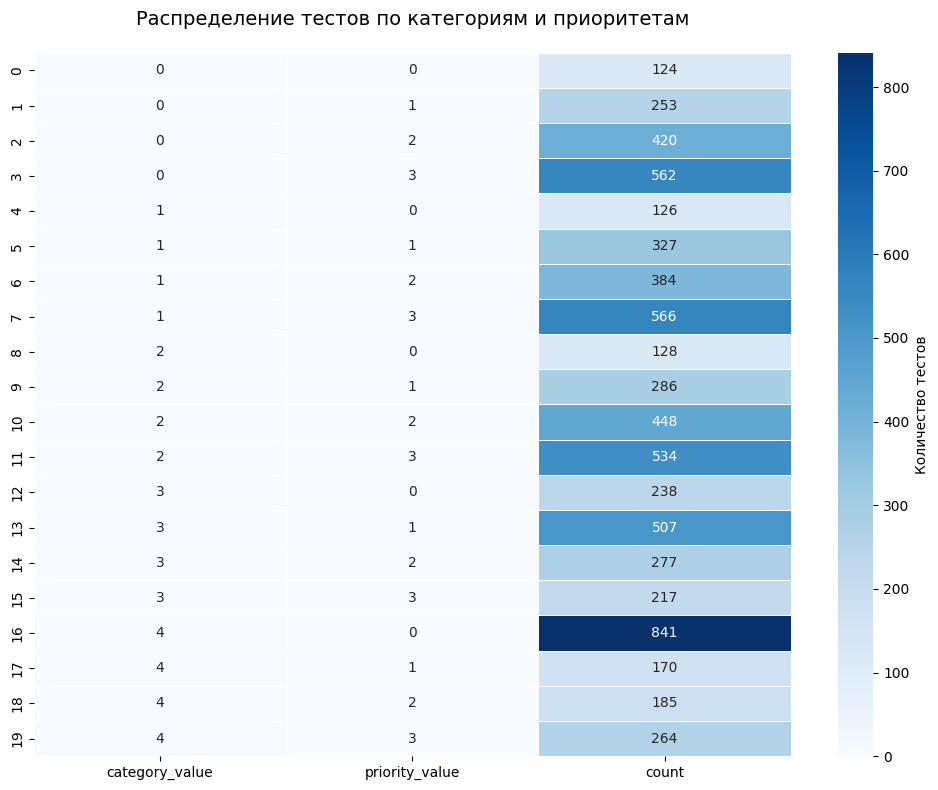

In [176]:
plt.figure(figsize=(10, 8))
ax = sns.heatmap(summary, 
            annot=True,           # Показывать числа в ячейках
            fmt='g',              # Формат чисел (целые)
            cmap='Blues',         # Цветовая схема
            linewidths=0.5,       # Тонкие линии между ячейками
            linecolor='white',    # Цвет линий
            cbar_kws={'label': 'Количество тестов'},
)

plt.title('Распределение тестов по категориям и приоритетам', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

In [ ]:
len(tests_list)

In [ ]:
# Сохранить весь датасет в файл FullDataset.csv
def save_data_to_csv(dataset, filename='FullDataset.csv'):
    """Сохраняет Counter в CSV файл"""
    data = []
    for d in dataset:
        if d['category'] == 1:
            d['category'] = 2
        try:
            data.append({
                'text': d['text'],
                'category': Category(d['category']).name,
                'category_value': d['category'],
                'priority': Priority(d['priority']).name,
                'priority_value': d['priority'],
            })
        except Exception as e:
            print(d, e)
    df_out = pd.DataFrame(data)
    df_out.to_csv(filename, index=False)
    print(f"\n💾 Данные сохранены в {filename}")
    return df_out

In [ ]:
save_data_to_csv(tests_list)

In [ ]:
tests_list

# Работа с отдельными файлами датасета

In [159]:
dataset_name = "DatasetFiles/json_dataset.csv"

In [160]:
df = pd.read_csv(dataset_name)

In [163]:
print(min(df["priority_value"]), max(df["priority_value"]))
print(min(df["category_value"]), max(df["category_value"]))

0 3
0 4


In [162]:
df["priority_value"] = df["priority_value"].replace(4, 3)

In [149]:
df['priority_value'] -= 2
df['category_value'] -= 1

In [150]:
any(df['priority_value'] >= 5)

False

In [164]:
df

,text,category_value,priority_value
0,"Не могу оплатить заказ, карта отклонена",0,3
1,Когда вернут деньги за отмененный заказ?,0,2
2,Ошибка при оплате: insufficient funds,0,3
3,"Списали деньги дважды, а заказ один",0,3
4,Как изменить способ оплаты после оформления?,0,1
...,...,...,...
607,"Мне начислили 500 приветственных баллов, но я ...",2,2
608,"Заказ пришел в помятой упаковке, сам товар (ст...",1,3
609,Интересуют оптовые закупки вашей продукции для...,4,1
610,"Подскажите габариты упаковки холодильника, арт...",3,1


In [165]:
df.to_csv(dataset_name, index=False)

# Загрузка из csv

In [13]:
total_tests = 0
tests_list = []
total_df = pd.DataFrame()
for file in os.listdir(dataset_path):
    if not file.endswith('.csv') or file == 'dataset.csv':
        continue
    
    file_path = os.path.join(dataset_path, file)
    print(file_path)
    df = pd.read_csv(file_path)
    print(len(df[df['priority_value'] == 0]) / len(df))
    total_df = pd.concat([total_df, df])

DatasetFiles/support_dataset_small_long_v2.csv
0.25
DatasetFiles/dataset_chat_gpt.csv
0.25511432009626955
DatasetFiles/support_dataset_2000.csv
0.25
DatasetFiles/json_dataset.csv
0.2238562091503268
DatasetFiles/dataset_gemini.csv
0.23115079365079366
DatasetFiles/support_data.csv
0.23115079365079366


In [14]:
total_df

,text,category_value,priority_value
0,"Добрый вечер, я столкнулся с проблемой при опл...",0,0
1,"Приветствую, у меня возникла странная ситуация...",0,0
2,"Приветствую, при попытке оплаты возникает ошиб...",0,0
3,"Приветствую, система списала деньги, но заказ ...",0,0
4,"Здравствуйте, я столкнулся с проблемой при опл...",0,0
...,...,...,...
1003,"Здравствуйте! Подскажите, совместим ли данный ...",3,1
1004,Здравствуйте. Я хочу оформить возврат сложной ...,3,2
1005,ВНИМАНИЕ! Ваша банковская карта была выбрана д...,4,0
1006,Здравствуйте! Мы представляем сервис автоматиз...,4,0


# Обновление полного датасета (FullDataset.csv)

In [15]:
print(min(total_df["priority_value"]), max(total_df["priority_value"]))
print(min(total_df["category_value"]), max(total_df["category_value"]))

0 3
0 4


In [16]:
for i in range(4):
    print(len(total_df[total_df['priority_value'] == i]) / len(total_df))

0.24150878989588667
0.24850657108721624
0.2626728110599078
0.24731182795698925


In [58]:
total_df = total_df.fillna(0)

In [169]:
total_df["priority_value"] = total_df["priority_value"].astype(int)
total_df["category_value"] = total_df["category_value"].astype(int)

In [17]:
total_df.to_csv("FullDataset3.csv", index=False)